In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import zipfile

zip_path = '/content/drive/MyDrive/cats-dogs-project/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzipping!")

Done unzipping!


In [6]:
import os

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show files in first 2 levels
        for file in files[:3]:  # show just first 3 files as sample
            print(f'{indent}  {file}')


data/
  PetImages/
    Cat/
    Dog/


In [7]:
import os, shutil, random

cats_dir = '/content/data/PetImages/Cat'
dogs_dir = '/content/data/PetImages/Dog'

# Create destination folders
for split in ['train', 'validation', 'test']:
    for category in ['cats', 'dogs']:
        os.makedirs(f'/content/data/{split}/{category}', exist_ok=True)

def split_and_copy(src_dir, category):
    # Some images in this dataset are corrupted, this filters them out
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.shuffle(files)
    n = len(files)

    splits = {
        'train':      files[:int(0.8 * n)],
        'validation': files[int(0.8 * n):int(0.9 * n)],
        'test':       files[int(0.9 * n):]
    }

    for split, filelist in splits.items():
        for fname in filelist:
            shutil.copy(f'{src_dir}/{fname}', f'/content/data/{split}/{category}/{fname}')

    print(f'{category} → train: {len(splits["train"])}, val: {len(splits["validation"])}, test: {len(splits["test"])}')

split_and_copy(cats_dir, 'cats')
split_and_copy(dogs_dir, 'dogs')

cats → train: 9999, val: 1250, test: 1250
dogs → train: 9999, val: 1250, test: 1250


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize pixel values from 0-255 to 0.0-1.0
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/data/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    '/content/data/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/data/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


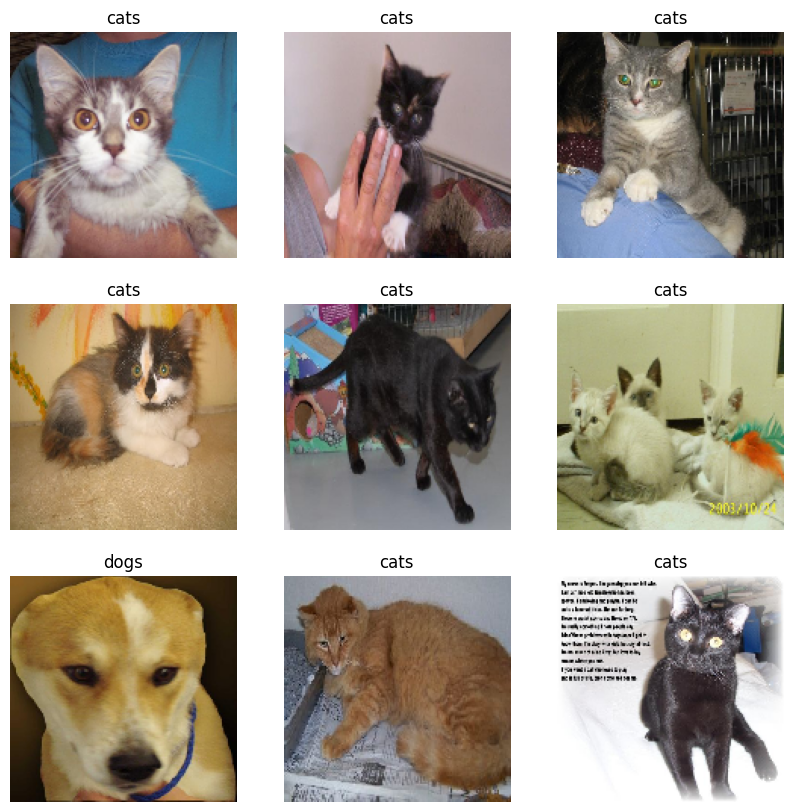

In [9]:
import matplotlib.pyplot as plt

# Grab one batch of images and their labels
images, labels = next(train_generator)

class_names = ['cats', 'dogs']

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()


In [19]:
import os
for f in os.listdir('/content'):
    if f.endswith('.ipynb'):
        print(f)


In [13]:
# Set your identity
!git config --global user.email "syedrafiuddin@edu.bme.hu"
!git config --global user.name "syedrafiuddin01"

# Clone your friend's repo
!git clone https://github.com/ishraspk22/MyiML.git

Cloning into 'MyiML'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
